# Baseline sensitivity study

Under correctly specified DGP assumptions, how much do the basic and loss-given-cure formulas diverge from the re-default-aware formula, and how does that gap move with $P_{rd}$, $PC$, and cure timing?

Each cell below sweeps one DGP parameter, holding the others at the base case ($PC \approx 0.2$, $P_{rd} \approx 0.1$, mean cure month $= 5$), and records each formula's relative error against $LGD_{true}$ across many replications per sweep value. Each sweep has an error chart showing relative error against $LGD_{true}$; a combined chart with LGD levels alongside the error is built once, at the end, from all three sweeps together. Charts and summary tables are saved to `results/`.

In [ ]:
import numpy as np

from lgd_sim.dgp import DGPParams
from lgd_sim.experiment import run_baseline
from lgd_sim.metrics import summarize
from lgd_sim.plotting import plot_bias_sweep, plot_sweep_grid, save_grayscale_check

SEED = 42
N_EXPOSURES = 10_000
N_REPLICATIONS = 1_000
BASE_PARAMS = DGPParams(pc=0.2, prd=0.1)
RESULTS_DIR = "../results"

## Sweep 1: $P_{rd}$, at $PC = 0.2$

In [2]:
prd_values = np.arange(0.0, 0.51, 0.05).round(2)

prd_results = run_baseline(
    sweep_param="prd",
    sweep_values=prd_values,
    base_params=BASE_PARAMS,
    n_exposures=N_EXPOSURES,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)
prd_summary = summarize(prd_results, sweep_param="prd")
prd_summary.to_csv(f"{RESULTS_DIR}/baseline_prd_summary.csv", index=False)
prd_summary

,prd,lgd_basic_error_mean,lgd_basic_error_sd,lgd_lgc_error_mean,lgd_lgc_error_sd,lgd_prd_error_mean,lgd_prd_error_sd,lgd_new_error_mean,lgd_new_error_sd,lgd_true_mean,lgd_true_sd,lgd_basic_mean,lgd_basic_sd,lgd_lgc_mean,lgd_lgc_sd,lgd_prd_mean,lgd_prd_sd,lgd_new_mean,lgd_new_sd,n_replications
0,0.00,0.000066,0.002109,0.000066,0.002109,0.000066,0.002109,0.000066,0.002109,0.399974,0.004086,0.399998,0.003985,0.399998,0.003985,0.399998,0.003985,0.399998,0.003985,1000
1,0.05,-0.003930,0.002112,0.002410,0.002250,0.006013,0.002208,0.000022,0.002075,0.402610,0.003950,0.401026,0.003860,0.403578,0.003888,0.405029,0.003902,0.402617,0.003876,1000
2,0.10,-0.007850,0.002205,0.004667,0.002421,0.012003,0.002371,0.000052,0.002112,0.405105,0.004217,0.401924,0.004119,0.406994,0.004144,0.409966,0.004170,0.405125,0.004144,1000
3,0.15,-0.011892,0.002342,0.006578,0.002576,0.017732,0.002522,-0.000038,0.002196,0.407860,0.004184,0.403007,0.004002,0.410540,0.004065,0.415089,0.004085,0.407842,0.004044,1000
4,0.20,-0.015847,0.002395,0.008391,0.002730,0.023595,0.002645,-0.000024,0.002194,0.410253,0.004120,0.403750,0.003977,0.413693,0.004039,0.419930,0.004114,0.410241,0.004030,1000
5,0.25,-0.019780,0.002393,0.010084,0.002777,0.029341,0.002690,0.000010,0.002185,0.412817,0.004278,0.404650,0.004137,0.416977,0.004226,0.424927,0.004286,0.412819,0.004202,1000
6,0.30,-0.023645,0.002509,0.011539,0.002979,0.034752,0.002957,0.000003,0.002287,0.415789,0.004167,0.405956,0.003971,0.420584,0.004032,0.430235,0.004091,0.415788,0.004039,1000
7,0.35,-0.027764,0.002606,0.012733,0.002995,0.040360,0.002890,-0.000145,0.002301,0.418222,0.004210,0.406609,0.004027,0.423544,0.004107,0.435099,0.004234,0.418160,0.004108,1000
8,0.40,-0.031525,0.002618,0.013960,0.003176,0.045900,0.002983,0.000013,0.002337,0.420640,0.003997,0.407377,0.003797,0.426508,0.003923,0.439943,0.003971,0.420643,0.003891,1000
9,0.45,-0.035492,0.002675,0.014957,0.003140,0.051379,0.003219,-0.000064,0.002361,0.423316,0.004244,0.408289,0.003980,0.429644,0.004145,0.445061,0.004261,0.423286,0.004121,1000


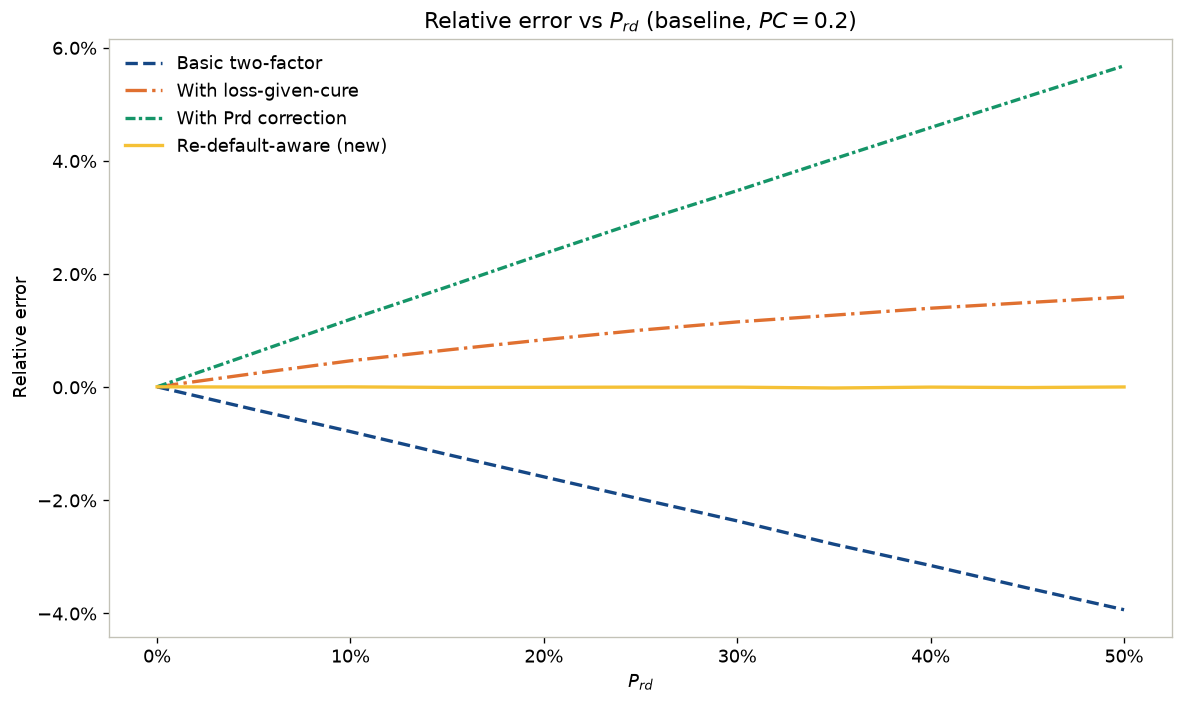

In [3]:
fig = plot_bias_sweep(
    prd_summary,
    sweep_param="prd",
    x_label="$P_{rd}$",
    title="Relative error vs $P_{rd}$ (baseline, $PC=0.2$)",
)
fig.savefig(f"{RESULTS_DIR}/baseline_bias_vs_prd.png", bbox_inches="tight")

The re-default-aware formula tracks true LGD closely across the full range: its line sits on top of the emphasized true-LGD line in the levels chart, and its error stays within a fraction of a percentage point of zero in the error chart. The basic formula drifts to about -4% relative error by $P_{rd}=50\%$, the loss-given-cure add-on to about +1.6%, and the Prd-correction to about +5.7% in the other direction.

## Sweep 2: $PC$, at $P_{rd} = 0.1$

In [4]:
pc_values = np.arange(0.05, 0.51, 0.05).round(2)

pc_results = run_baseline(
    sweep_param="pc",
    sweep_values=pc_values,
    base_params=BASE_PARAMS,
    n_exposures=N_EXPOSURES,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)
pc_summary = summarize(pc_results, sweep_param="pc")
pc_summary.to_csv(f"{RESULTS_DIR}/baseline_pc_summary.csv", index=False)
pc_summary

,pc,lgd_basic_error_mean,lgd_basic_error_sd,lgd_lgc_error_mean,lgd_lgc_error_sd,lgd_prd_error_mean,lgd_prd_error_sd,lgd_new_error_mean,lgd_new_error_sd,lgd_true_mean,lgd_true_sd,lgd_basic_mean,lgd_basic_sd,lgd_lgc_mean,lgd_lgc_sd,lgd_prd_mean,lgd_prd_sd,lgd_new_mean,lgd_new_sd,n_replications
0,0.05,-0.002288,0.001753,0.000434,0.001805,0.002683,0.001774,0.000150,0.001709,0.476086,0.004102,0.474995,0.003986,0.476290,0.003984,0.477361,0.003996,0.476156,0.003988,1000
1,0.10,-0.004563,0.001934,0.001061,0.001996,0.005356,0.001928,0.000042,0.001847,0.452482,0.004167,0.450416,0.004081,0.452960,0.004107,0.454904,0.004105,0.452499,0.004097,1000
2,0.15,-0.006361,0.002001,0.002498,0.002118,0.008495,0.002121,0.000057,0.001931,0.428916,0.004026,0.426186,0.003959,0.429986,0.003971,0.432558,0.004004,0.428939,0.003973,1000
3,0.20,-0.007854,0.002189,0.004699,0.002395,0.012030,0.002339,0.000088,0.002082,0.405232,0.004106,0.402048,0.003967,0.407134,0.003994,0.410105,0.004024,0.405266,0.003997,1000
4,0.25,-0.008954,0.002479,0.007531,0.002780,0.015800,0.002688,-0.000022,0.002365,0.381439,0.004166,0.378021,0.003993,0.384308,0.004043,0.387463,0.004092,0.381428,0.004031,1000
5,0.30,-0.009464,0.002603,0.011587,0.002933,0.020209,0.002803,-0.000020,0.002473,0.357987,0.004281,0.354596,0.004080,0.362131,0.004106,0.365218,0.004151,0.357977,0.004125,1000
6,0.35,-0.009249,0.002867,0.016874,0.003392,0.025352,0.003201,0.000087,0.002738,0.333886,0.004169,0.330795,0.003985,0.339516,0.004047,0.342347,0.004113,0.333912,0.004036,1000
7,0.40,-0.008493,0.003089,0.023617,0.003832,0.031244,0.003542,0.000003,0.002934,0.310437,0.003992,0.307797,0.003802,0.317764,0.003907,0.320132,0.003961,0.310435,0.003878,1000
8,0.45,-0.006838,0.003282,0.031942,0.004168,0.037970,0.003820,-0.000090,0.003072,0.286796,0.003929,0.284831,0.003774,0.295952,0.003925,0.297682,0.003964,0.286768,0.003869,1000
9,0.50,-0.003862,0.003658,0.042934,0.004776,0.045958,0.004314,-0.000005,0.003481,0.263135,0.003762,0.262115,0.003614,0.274427,0.003774,0.275224,0.003802,0.263131,0.003708,1000


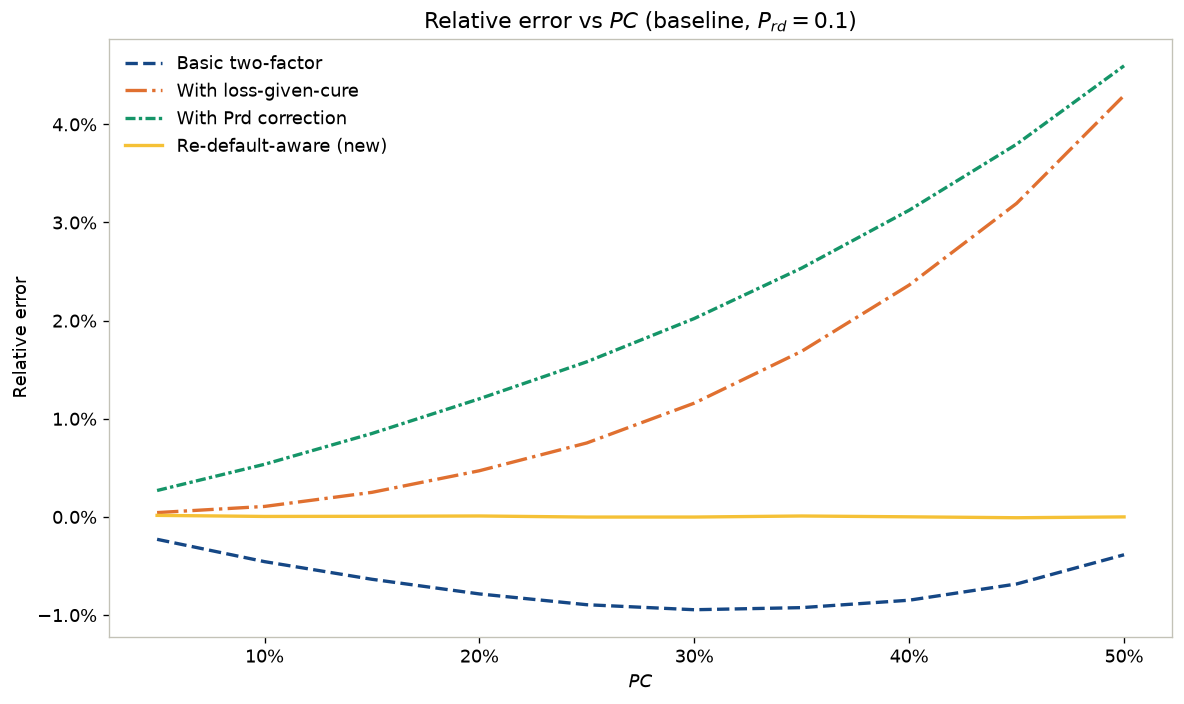

In [5]:
fig = plot_bias_sweep(
    pc_summary,
    sweep_param="pc",
    x_label="$PC$",
    title="Relative error vs $PC$ (baseline, $P_{rd}=0.1$)",
)
fig.savefig(f"{RESULTS_DIR}/baseline_bias_vs_pc.png", bbox_inches="tight")

The pattern holds across $PC$ too, with one difference in shape: the basic formula's error is a U-curve, dipping to about -1% around $PC=25$-$30\%$ before recovering toward -0.4% at $PC=50\%$, rather than the monotonic drift seen in the $P_{rd}$ sweep. The loss-given-cure and Prd-correction formulas both grow roughly monotonically with $PC$, reaching about +4.3% and +4.6% respectively at $PC=50\%$. The re-default-aware formula again stays close to zero across the whole range.

## Sweep 3: mean cure month, at $PC = 0.2$, $P_{rd} = 0.1$

Swept 1 to 20 months against a 60-month maturity, so the cured interval stays a minority of the loan's remaining term across the whole range.

In [6]:
cure_month_values = np.arange(1, 21)

cure_month_results = run_baseline(
    sweep_param="mean_cure_month",
    sweep_values=cure_month_values,
    base_params=BASE_PARAMS,
    n_exposures=N_EXPOSURES,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)
cure_month_summary = summarize(cure_month_results, sweep_param="mean_cure_month")
cure_month_summary.to_csv(f"{RESULTS_DIR}/baseline_cure_month_summary.csv", index=False)
cure_month_summary

,mean_cure_month,lgd_basic_error_mean,lgd_basic_error_sd,lgd_lgc_error_mean,lgd_lgc_error_sd,lgd_prd_error_mean,lgd_prd_error_sd,lgd_new_error_mean,lgd_new_error_sd,lgd_true_mean,lgd_true_sd,lgd_basic_mean,lgd_basic_sd,lgd_lgc_mean,lgd_lgc_sd,lgd_prd_mean,lgd_prd_sd,lgd_new_mean,lgd_new_sd,n_replications
0,1,-0.008744,0.002180,0.004565,0.002338,0.011166,0.002259,0.000008,0.002063,0.405667,0.004002,0.402118,0.003896,0.407517,0.003934,0.410195,0.003958,0.405669,0.003919,1000
1,2,-0.008609,0.002221,0.004552,0.002470,0.011274,0.002377,-0.000060,0.002147,0.405411,0.003989,0.401919,0.003878,0.407255,0.003930,0.409980,0.003961,0.405385,0.003914,1000
2,3,-0.008249,0.002299,0.004642,0.002490,0.011529,0.002416,0.000041,0.002201,0.405255,0.004278,0.401909,0.004158,0.407133,0.004183,0.409924,0.004210,0.405269,0.004181,1000
3,4,-0.008160,0.002135,0.004523,0.002344,0.011685,0.002279,-0.000057,0.002070,0.405410,0.004216,0.402100,0.004104,0.407242,0.004125,0.410145,0.004141,0.405386,0.004132,1000
4,5,-0.007948,0.002199,0.004548,0.002436,0.011921,0.002357,-0.000024,0.002121,0.405194,0.004328,0.401972,0.004175,0.407035,0.004210,0.410022,0.004269,0.405183,0.004211,1000
5,6,-0.007805,0.002189,0.004458,0.002368,0.012043,0.002303,-0.000138,0.002103,0.405208,0.004103,0.402044,0.004032,0.407013,0.004077,0.410087,0.004118,0.405151,0.004067,1000
6,7,-0.007480,0.002273,0.004640,0.002447,0.012324,0.002440,0.000025,0.002184,0.404982,0.004057,0.401951,0.003923,0.406859,0.003962,0.409970,0.003984,0.404990,0.003960,1000
7,8,-0.007322,0.002292,0.004519,0.002475,0.012465,0.002439,-0.000066,0.002188,0.404870,0.004076,0.401903,0.003934,0.406697,0.003964,0.409914,0.004008,0.404841,0.003962,1000
8,9,-0.007055,0.002202,0.004685,0.002447,0.012820,0.002355,0.000045,0.002125,0.404684,0.004071,0.401827,0.003995,0.406578,0.004044,0.409870,0.004057,0.404701,0.004033,1000
9,10,-0.006934,0.002199,0.004606,0.002443,0.012994,0.002428,-0.000028,0.002135,0.404683,0.004018,0.401875,0.003934,0.406544,0.003952,0.409939,0.003978,0.404670,0.003955,1000


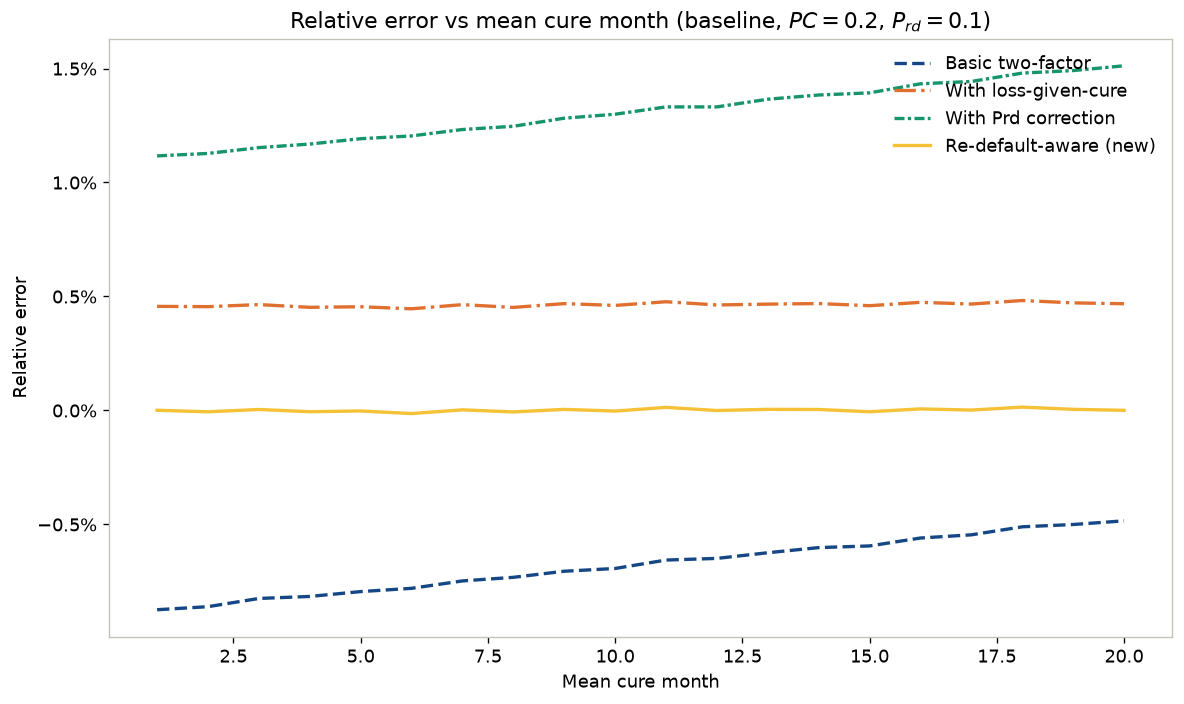

In [7]:
fig = plot_bias_sweep(
    cure_month_summary,
    sweep_param="mean_cure_month",
    x_label="Mean cure month",
    title="Relative error vs mean cure month (baseline, $PC=0.2$, $P_{rd}=0.1$)",
    x_as_percent=False,
)
fig.savefig(f"{RESULTS_DIR}/baseline_bias_vs_cure_month.png", bbox_inches="tight")

Cure timing moves all four formulas far less than $P_{rd}$ or $PC$ do. The basic formula sits around -0.5% to -0.9%, the loss-given-cure add-on is essentially flat around +0.5%, and the Prd-correction drifts slowly from about +1.1% to +1.5% as the mean cure month grows from 1 to 20. The re-default-aware formula stays flat at zero throughout, confirming the correction isn't sensitive to this particular timing assumption within the range tested.

## Final results

The three sweeps above, combined into one figure for the write-up.

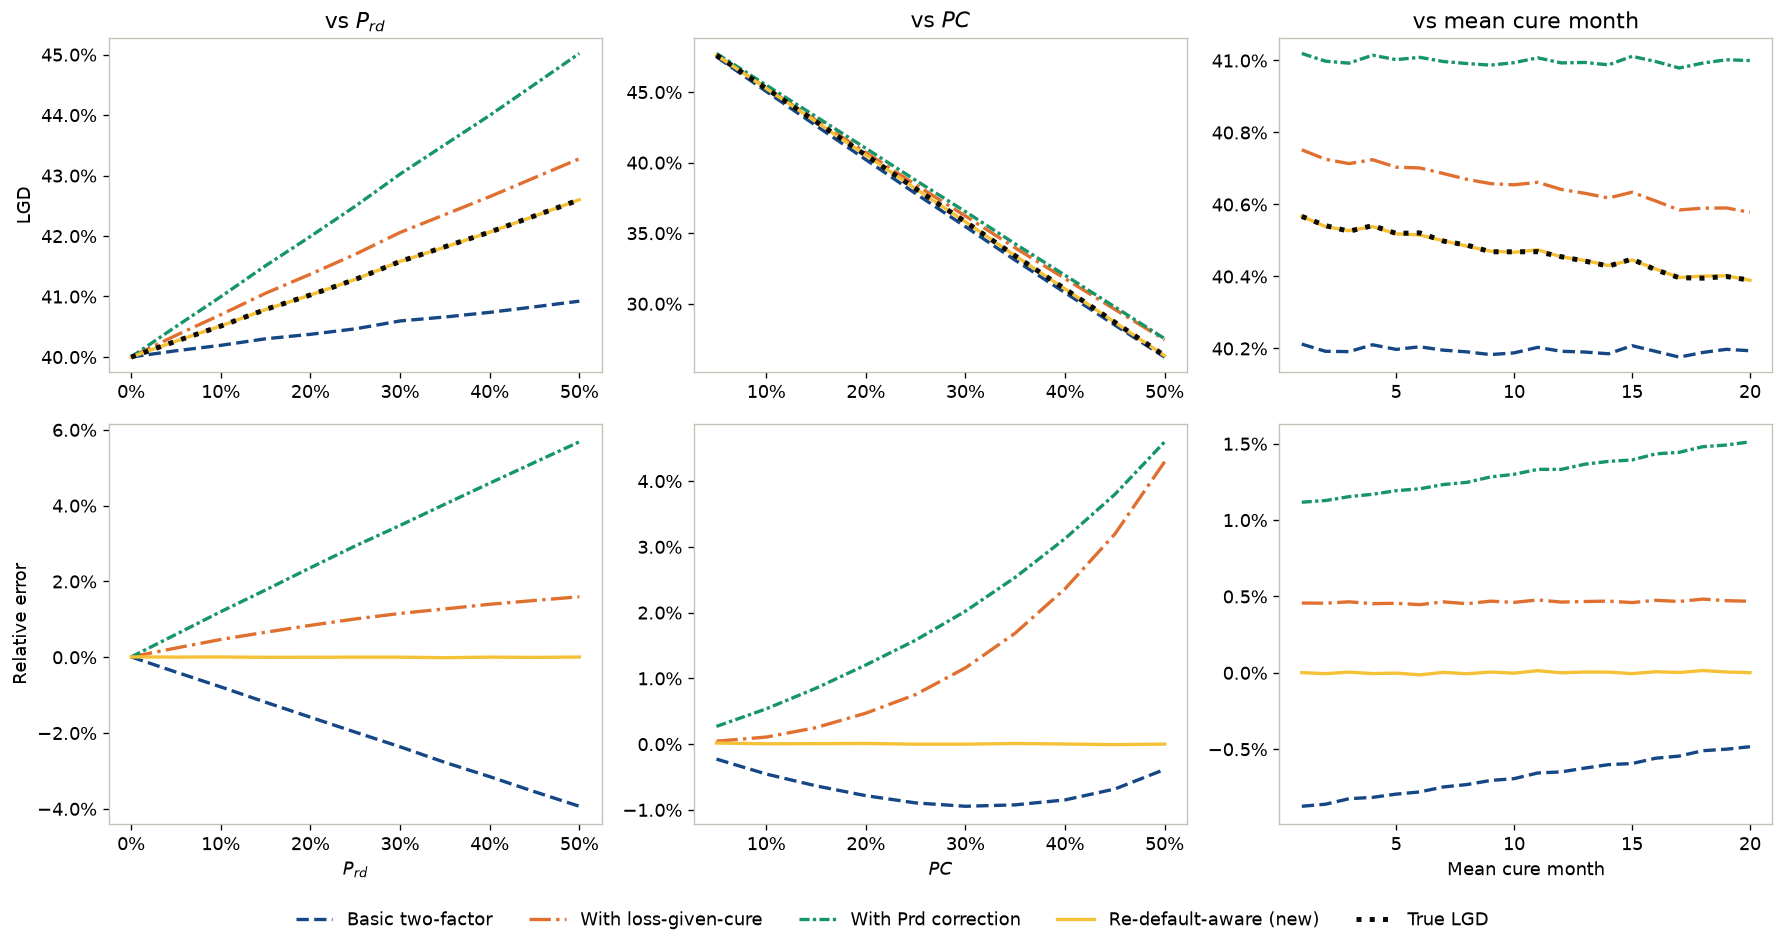

In [8]:
fig = plot_sweep_grid(
    [
        {
            "summary": prd_summary,
            "sweep_param": "prd",
            "x_label": "$P_{rd}$",
            "title": "vs $P_{rd}$",
        },
        {
            "summary": pc_summary,
            "sweep_param": "pc",
            "x_label": "$PC$",
            "title": "vs $PC$",
        },
        {
            "summary": cure_month_summary,
            "sweep_param": "mean_cure_month",
            "x_label": "Mean cure month",
            "title": "vs mean cure month",
            "x_as_percent": False,
        },
    ]
)
fig.savefig(f"{RESULTS_DIR}/baseline_summary_grid.png", bbox_inches="tight")

In [9]:
save_grayscale_check(fig, f"{RESULTS_DIR}/baseline_summary_grid_grayscale_check.png")

## Summary

Across all three axes, the re-default-aware formula's bias stays close to zero, while the basic, loss-given-cure, and Prd-correction formulas each diverge in a different direction and by a different amount depending on which parameter moves. $P_{rd}$ has the largest effect on the size of the gap, $PC$ produces the same qualitative pattern with a different shape for the basic formula, and cure timing has comparatively little effect on any of the four.

One caveat: the re-default-aware formula was derived from the same cash-flow accounting identity this simulation's $LGD_{true}$ is computed from. Recovering it almost exactly here is mostly a check that the algebra and the code agree with each other, rather than independent evidence the formula will outperform on a real, un-simulated portfolio. The more informative result of this experiment is the qualitative direction of the other three formulas' bias, basic underestimating and the other two overestimating in different ways. Whether the re-default-aware formula's advantage survives when the DGP's own assumptions are violated is what the misspecification experiment is for.